<a href="https://colab.research.google.com/github/Mansi-3s/Creditt_wise_loan/blob/main/Data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Augmentation for Image Data







In [ ]:
#IMPORT LIBRARY

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential

### Loading MNIST Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Defining Image_Datagenerator

In [ ]:
datagen = ImageDataGenerator(
   rotation_range=15,       # rotate images by ±15 degrees
   width_shift_range=0.1,   # 10% horizontal shift
   height_shift_range=0.1,  # 10% vertical shift
   zoom_range=0.1,          # zoom in/out by 10%
   shear_range=0.1,         # apply shear transformation
   horizontal_flip=False,   # not needed for digits
   fill_mode='nearest'      # fill missing pixels after transformations
)

### Building Simple CNN_Model

In [ ]:
model = Sequential([
   Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
   MaxPooling2D((2, 2)),
   Conv2D(64, (3, 3), activation='relu'),
   MaxPooling2D((2, 2)),
   Flatten(),
   Dropout(0.3),
   Dense(64, activation='relu'),
   Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Training th Model

In [ ]:
batch_size = 64
epochs = 5

history = model.fit(
   datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True),
   steps_per_epoch=len(X_train)//batch_size,
   epochs=epochs,
   validation_data=(X_test, y_test)
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


937/937 ━━━━━━━━━━━━━━━━━━━━ 75s 78ms/step - accuracy: 0.7544 - loss: 0.7386 - val_accuracy: 0.9811 - val_loss: 0.0626
Epoch 2/5
  1/937 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9531 - loss: 0.1658

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9531 - loss: 0.1658 - val_accuracy: 0.9803 - val_loss: 0.0653
Epoch 3/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9474 - loss: 0.1700 - val_accuracy: 0.9855 - val_loss: 0.0411
Epoch 4/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9844 - loss: 0.0572 - val_accuracy: 0.9861 - val_loss: 0.0393
Epoch 5/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.9647 - loss: 0.1145 - val_accuracy: 0.9891 - val_loss: 0.0348


### Visualizing Augmented Images

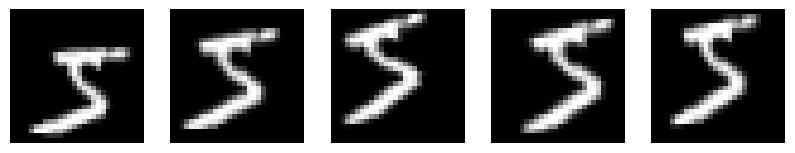

In [ ]:
import matplotlib.pyplot as plt

# Visualize five augmented variants of the first training sample
plt.figure(figsize=(10, 2))
for i, batch in enumerate(datagen.flow(X_train[:1], batch_size=1)):
   plt.subplot(1, 5, i + 1)
   plt.imshow(batch[0].reshape(28, 28), cmap='gray')
   plt.axis('off')
   if i == 4:
       break
plt.show()

### Data Augmentation for Textual Data :

Text is more delicate. You can’t randomly replace words without thinking about meaning. But small, controlled changes can help your model generalize. A simple example using synonym replacement (with NLTK): Use RNN

In [ ]:
import nltk
from nltk.corpus import wordnet
import random

nltk.download("wordnet")
nltk.download("omw-1.4")


def synonym_replacement(sentence):
    words = sentence.split()
    idx = random.randint(0, len(words) - 1)
    word = words[idx]
    synsets = wordnet.synsets(word)
    synonyms = set()

    for syn in synsets:
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)

    if len(synonyms) > 0:
        words[idx] = random.choice(list(synonyms))

    return " ".join(words)


text = "The movie was really good"

print("Original:", text)
print("Augmented:", synonym_replacement(text))

Original: The movie was really good
Augmented: The movie embody really good


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Data Augmentation for Audio Data

You should observe that the audio is loaded at 22,050 Hz. Now, adding noise does not change its length, so the noisy audio is the same size as the original. Time stretching speeds up the audio while preserving content.

In [ ]:
import librosa
import numpy as np

# Load built-in trumpet audio from librosa
audio_path = librosa.ex("trumpet")
audio, sr = librosa.load(audio_path, sr=None)

# Add background noise
noise = np.random.randn(len(audio))
audio_noisy = audio + 0.005 * noise

# Time stretching
audio_stretched = librosa.effects.time_stretch(audio, rate=1.1)

print("Sample rate:", sr)
print("Original length:", len(audio))
print("Noisy length:", len(audio_noisy))
print("Stretched length:", len(audio_stretched))

Sample rate: 22050
Original length: 117601
Noisy length: 117601
Stretched length: 106910


### Data Augmentation for Tabular Data

In [ ]:
import numpy as np
import pandas as pd

# Sample tabular dataset
data = {
    "age": [25, 30, 35, 40],
    "income": [40000, 50000, 60000, 70000],
    "credit_score": [650, 700, 750, 800]
}

df = pd.DataFrame(data)

# Add small Gaussian noise to numerical columns
augmented_df = df.copy()
noise_factor = 0.02  # 2% noise

for col in augmented_df.columns:
    noise = np.random.normal(0, noise_factor, size=len(df))
    augmented_df[col] = augmented_df[col] * (1 + noise)

print(augmented_df)

         age        income  credit_score
0  24.582821  40477.663454    656.653758
1  31.125450  50486.951111    711.377838
2  34.283686  57709.916223    777.729777
3  37.750643  71879.586338    800.889335


### Data augmentation helps when data is limited, overfitting is present, and real-world variation exists. It does not fix incorrect labels, biased data, or poorly defined features. That’s why understanding your data always comes before applying transformations. It isn’t just a trick for competitions or deep learning demos. It’s a mindset shift. You don’t need to chase more data, but you have to start asking how your existing data might naturally change. Your models stop overfitting, start generalizing, and finally behave the way you expected them to in the first place.

In [85]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [86]:
img = image.load_img("/content/OIP.jpg", target_size=(200, 200))

In [87]:
import matplotlib.pyplot as plt

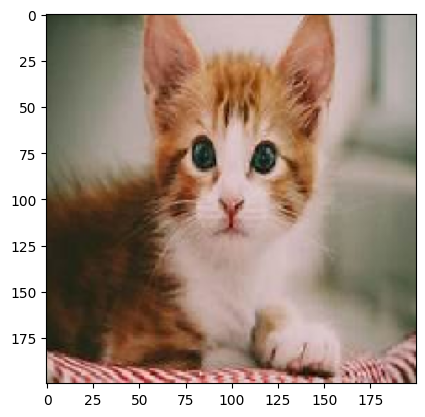

In [88]:
plt.imshow(img)

In [89]:
type(img)

PIL.Image.Image

In [105]:
datagen = ImageDataGenerator(
   rotation_range=40,       # rotate images by ±15 degrees
   width_shift_range=0.2,   # 10% horizontal shift
   height_shift_range=0.2,  # 10% vertical shift
   zoom_range=0.2,          # zoom in/out by 10%
   shear_range=0.2,         # apply shear transformation
   horizontal_flip=True,

   fill_mode='nearest'      # fill missing pixels after transformations
)

In [106]:
img = image.img_to_array(img)

In [107]:
img

array([[[ 44.,  55.,  38.],
        [ 45.,  56.,  39.],
        [ 46.,  57.,  40.],
        ...,
        [166., 167., 161.],
        [166., 167., 161.],
        [167., 168., 162.]],

       [[ 44.,  55.,  38.],
        [ 46.,  57.,  40.],
        [ 47.,  58.,  41.],
        ...,
        [165., 166., 160.],
        [165., 166., 160.],
        [166., 167., 161.]],

       [[ 46.,  57.,  40.],
        [ 48.,  59.,  42.],
        [ 49.,  60.,  43.],
        ...,
        [164., 165., 159.],
        [164., 165., 159.],
        [165., 166., 160.]],

       ...,

       [[165., 153., 139.],
        [167., 148., 133.],
        [157., 131., 114.],
        ...,
        [185., 155., 144.],
        [194., 168., 155.],
        [161., 139., 128.]],

       [[146., 134., 120.],
        [156., 137., 122.],
        [155., 129., 112.],
        ...,
        [163., 133., 122.],
        [189., 163., 150.],
        [177., 155., 144.]],

       [[132., 120., 106.],
        [151., 132., 117.],
        [162., 1

In [108]:
img.shape

(200, 200, 3)

In [109]:
input_batch = img.reshape(1, 200, 200, 3)

In [110]:
input_batch.shape

(1, 200, 200, 3)

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
import os

i = 0

for output in datagen.flow(input_batch, batch_size=1, save_to_dir = '/content/drive/MyDrive/aug/image'):
    i = i + 1
    if i == 10:
        break

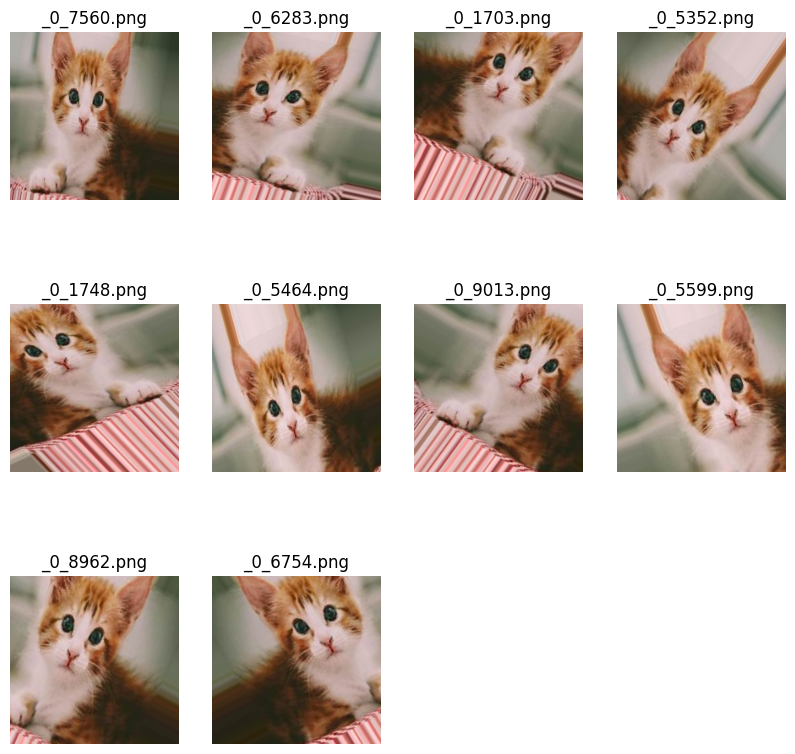

In [121]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

images = os.listdir(folder_path)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(images[:10]):   # first 10 images
    img_path = os.path.join(folder_path, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [122]:
images = sorted(os.listdir(folder_path))

In [115]:
input_batch.shape

(1, 200, 200, 3)